# Introduction to Kalman Filters in Finance

In quantitative finance, asset prices are notoriously noisy. To build robust trading algorithms, we often need to estimate the "true" underlying state of a system (like a trend, a spread, or a hedge ratio) from a series of noisy observations.

This notebook builds up the intuition for the **Kalman Filter**, starting from basic linear filters like Moving Averages, and culminating in a practical pairs trading application (dynamic beta estimation).

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pykalman import KalmanFilter

# Set formatting for plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

## 1. Simple Linear Filters: The Moving Average

The simplest way to filter noise is a Rolling Mean or Simple Moving Average (SMA). The SMA assumes that the true state of the price is the average of the last $N$ observations.

Let's download some price data and apply a 30-day and 90-day SMA.

[*********************100%***********************]  1 of 1 completed


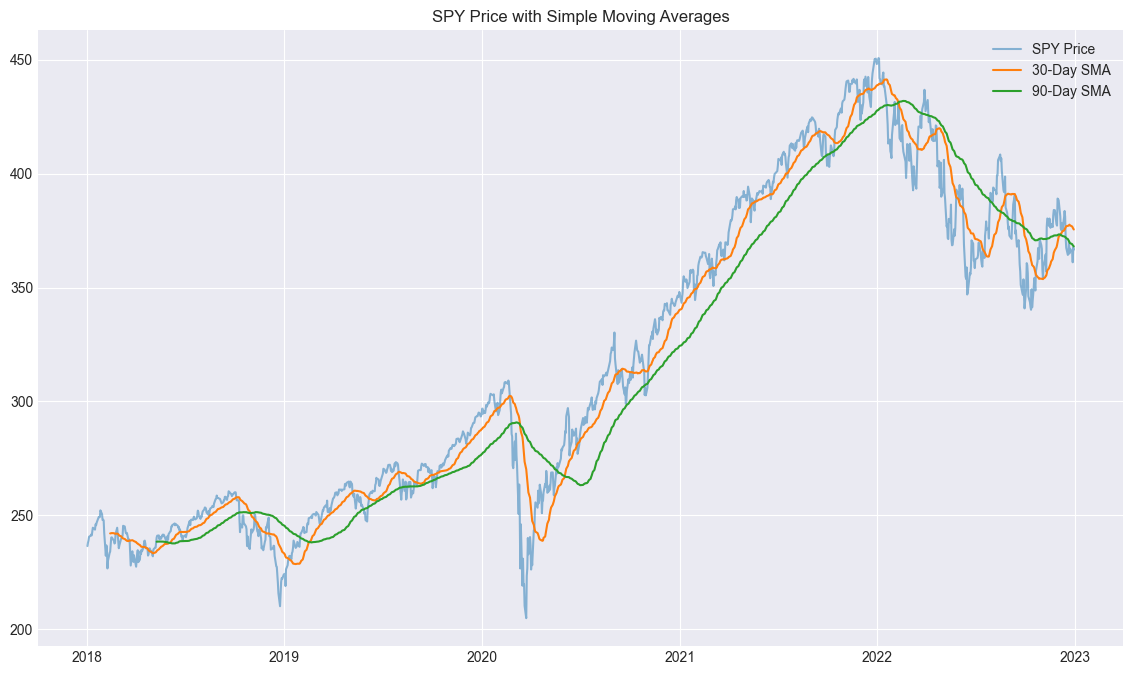

In [93]:
# Download SPY data
spy = yf.download('SPY', start='2018-01-01', end='2023-01-01')['Close']

# Calculate SMAs
sma_30 = spy.rolling(window=30).mean()
sma_90 = spy.rolling(window=90).mean()

# Plot
plt.plot(spy, label='SPY Price', alpha=0.5)
plt.plot(sma_30, label='30-Day SMA')
plt.plot(sma_90, label='90-Day SMA')
plt.title('SPY Price with Simple Moving Averages')
plt.legend()
plt.show()

### The Problem with Moving Averages: Lag
Notice the fundamental trade-off of moving averages:
1. A short window (30-day) reacts quickly but is still noisy.
2. A long window (90-day) is smooth but introduces massive **lag**. By the time the 90-day SMA turns, the trend has already been underway for weeks.

Exponential Moving Averages (EMA) improve this by overweighting recent data, but they still rely on a fixed, hard-coded lookback parameter. What if the market volatility changes? We want a filter that *dynamically* updates its confidence based on the noise level.

## 2. Enter the Kalman Filter

The Kalman Filter is an algorithm that uses a series of measurements observed over time (containing statistical noise) and produces estimates of unknown variables. It is an optimal estimator under certain mathematical conditions.

### The Two-Step Process
The filter operates in a continuous loop of two steps:
1. **Predict (Time Update):** Based on our mathematical model of the system, what do we think the state will be in the next time step?
2. **Update (Measurement Update):** We take a new measurement. We then update our prediction based on the difference between the prediction and the measurement, weighted by the **Kalman Gain**.

### The Kalman Gain
The Kalman Gain determines how much weight to give to the new measurement versus the model's prediction.
* If the measurement noise is **high**, the Kalman Gain is low, and we trust our model's prediction more.
* If the model's uncertainty is **high**, the Kalman Gain is high, and we trust the new measurement more.

### A 1D Kalman Filter Example

Let's model the price of an asset as a random walk. Our state is the "true" price, and our measurement is the observed market price.

* **State Transition:** $x_{t} = x_{t-1} + w_t$ (True price walks randomly)
* **Measurement:** $z_t = x_t + v_t$ (We observe the true price plus some noise)

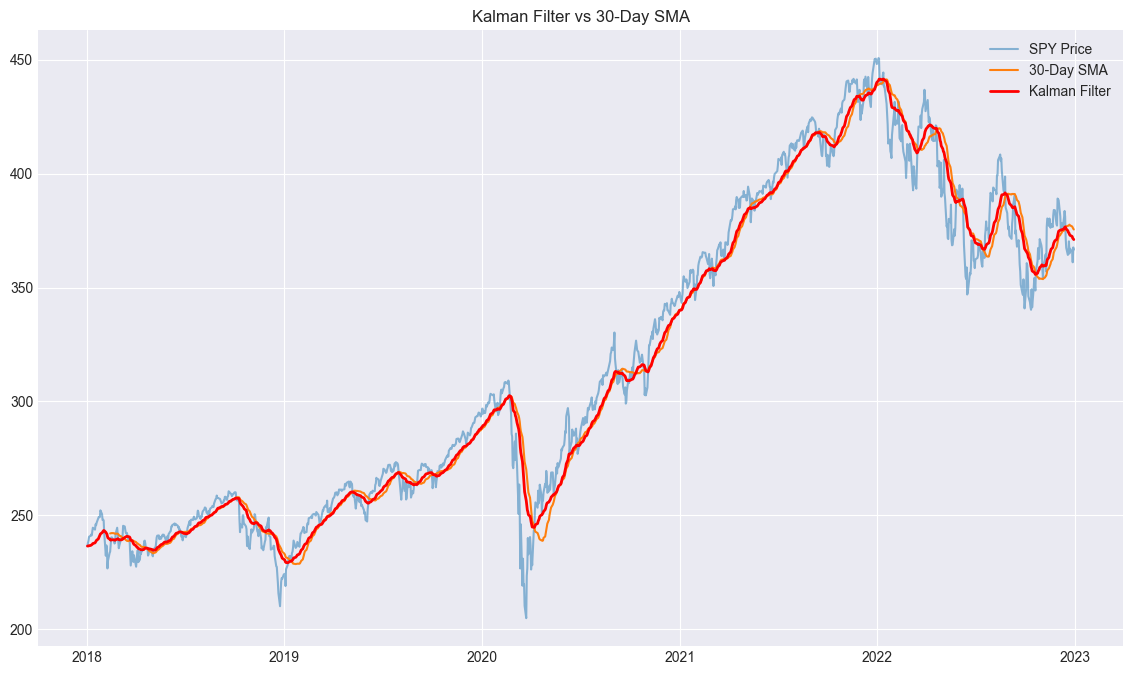

In [94]:
# Construct a Kalman Filter to act as a moving average
kf = KalmanFilter(
    transition_matrices = [1], # The state simply carries over
    observation_matrices = [1], # We observe the state directly
    initial_state_mean = spy.iloc[0],
    initial_state_covariance = 1,
    observation_covariance=100, # Increased realistic market noise variance
    transition_covariance=0.5 # Allowed flexibility so the filter tracks large SPY price movements
)

# Use the filter to smooth the SPY prices
# We use filter() instead of smooth() to avoid look-ahead bias in trading
state_means, _ = kf.filter(spy.values)
kalman_spy = pd.Series(state_means.flatten(), index=spy.index)

# Plot
plt.plot(spy, label='SPY Price', alpha=0.5)
plt.plot(sma_30, label='30-Day SMA')
plt.plot(kalman_spy, label='Kalman Filter', color='red', linewidth=2)
plt.title('Kalman Filter vs 30-Day SMA')
plt.legend()
plt.show()

Notice how the Kalman Filter adapts. It is generally as smooth as the 30-day SMA, but it responds to structural breaks much faster, exhibiting less lag. By tuning the `transition_covariance` and `observation_covariance`, you can adjust the filter's responsiveness.

## 3. Advanced Application: Predicting Asset Prices

The true power of the Kalman filter in finance shines in multi-dimensional problems.

Suppose we have two highly correlated assets, $Y$ and $X$. A standard way to predict $Y$ based on $X$ is to run a regression to find the hedge ratio (Beta) and intercept (Alpha):
$$Y_t = \alpha + \beta X_t + \epsilon_t$$

**The Problem:** The relationship between two assets is rarely static. If we use a rolling moving average regression, we face the same window-size dilemma (lag vs. noise).

**The Kalman Solution:** We can use the Kalman filter to dynamically update $\beta$ and $\alpha$, giving us a much more responsive prediction model.

Let's use two historically cointegrated ETFs: **GLD** (Gold) and **GDX** (Gold Miners).

[*********************100%***********************]  2 of 2 completed


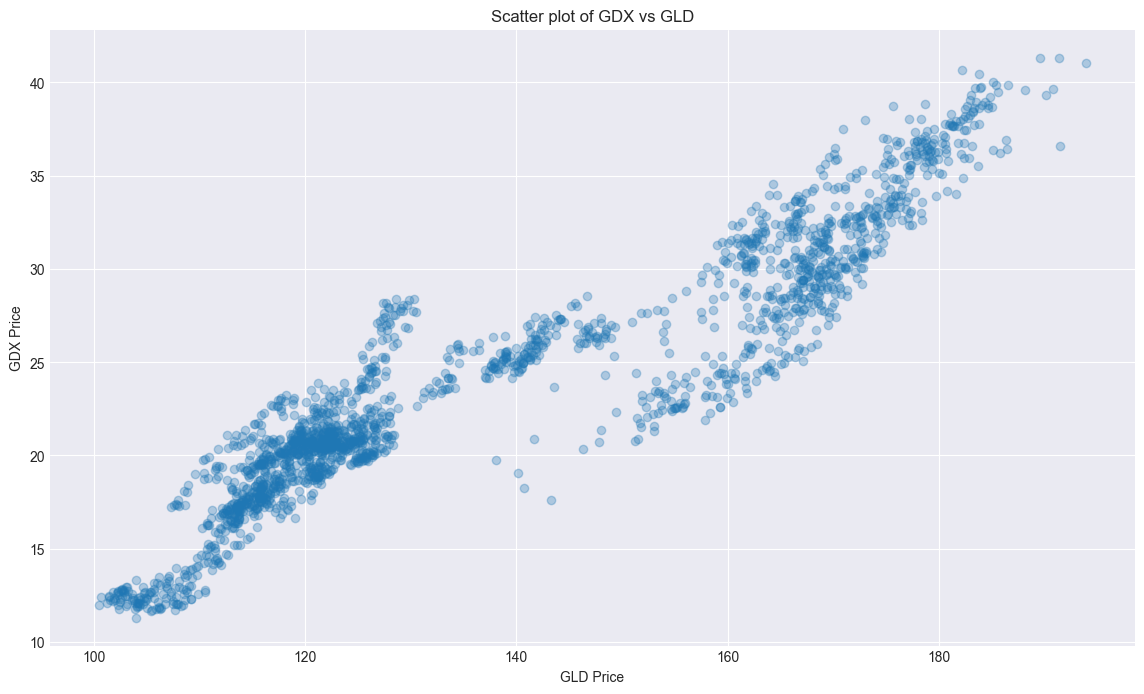

In [95]:
# Download data for GLD and GDX
pairs_data = yf.download(['GLD', 'GDX'], start='2015-01-01', end='2023-01-01')['Close']
pairs_data.dropna(inplace=True)

y = pairs_data['GDX']
x = pairs_data['GLD']

plt.scatter(x, y, alpha=0.3)
plt.xlabel('GLD Price')
plt.ylabel('GDX Price')
plt.title('Scatter plot of GDX vs GLD')
plt.show()

### Comparing Predictions: True Value vs Moving Average vs Kalman

We will track two hidden variables at each time step $t$: the intercept $\alpha_t$ and the slope $\beta_t$.
After calculating these dynamically, we will use them to predict the price of GDX.
We'll then compare this to a standard 60-day moving average (Rolling OLS) prediction, alongside the true GDX price.

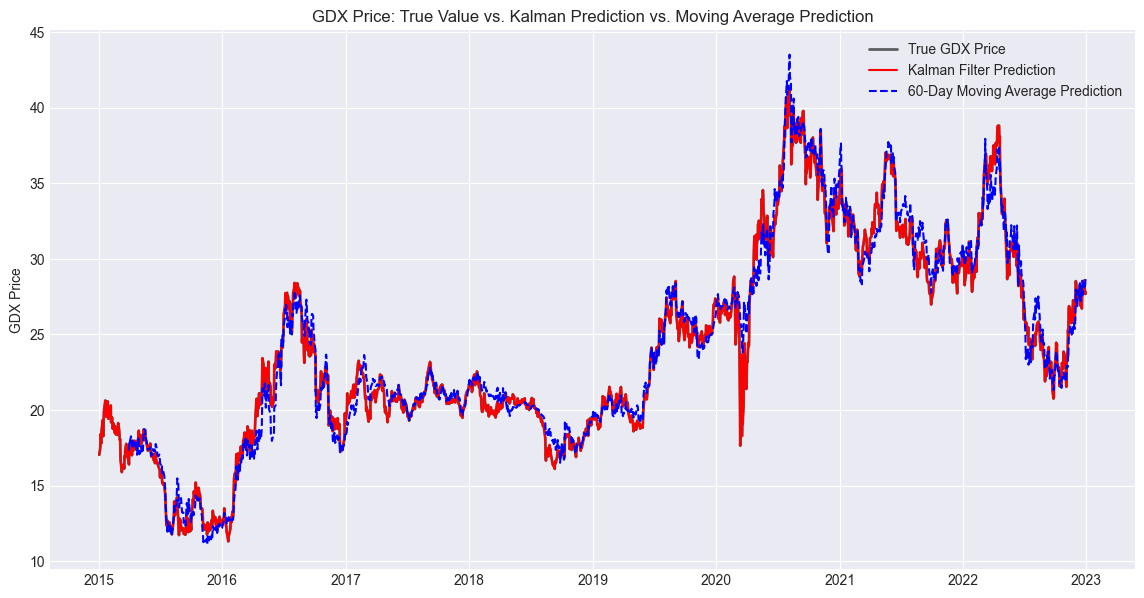

In [96]:
# 1. Calculate a realistic starting guess using the first 30 days of data
initial_beta = y.iloc[:30].cov(x.iloc[:30]) / x.iloc[:30].var()
initial_alpha = y.iloc[:30].mean() - (initial_beta * x.iloc[:30].mean())

# 2. Construct the observation matrix
obs_mat = np.vstack([np.ones(len(x)), x.values]).T[:, np.newaxis, :]

# 3. Set the flexibility (transition_covariance)
trans_cov = np.diag([1e-2, 1e-2]) 

# Initialize the Kalman Filter
kf_pairs = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    initial_state_mean=[initial_alpha, initial_beta], 
    initial_state_covariance=np.eye(2), 
    transition_matrices=np.eye(2),
    observation_matrices=obs_mat,
    observation_covariance=0.01,
    transition_covariance=trans_cov
)

# Run the filter to get our dynamic alpha and beta
state_means, state_covs = kf_pairs.filter(y.values)
dynamic_alpha = pd.Series(state_means[:, 0], index=x.index)
dynamic_beta = pd.Series(state_means[:, 1], index=x.index)

# Calculate a standard 60-day Moving Average (Rolling OLS) alpha and beta
rolling_cov = y.rolling(window=60).cov(x)
rolling_var = x.rolling(window=60).var()
rolling_beta = rolling_cov / rolling_var
rolling_alpha = y.rolling(window=60).mean() - (rolling_beta * x.rolling(window=60).mean())

# --- THE PREDICTIONS ---
# Predict the price of GDX using the GLD price and our estimated parameters
kalman_prediction = (dynamic_beta * x) + dynamic_alpha
ma_prediction = (rolling_beta * x) + rolling_alpha

# Plotting the True Price vs the Predictions
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(y, label='True GDX Price', color='black', alpha=0.6, linewidth=2)
ax.plot(kalman_prediction, label='Kalman Filter Prediction', color='red', linewidth=1.5)
ax.plot(ma_prediction, label='60-Day Moving Average Prediction', color='blue', linestyle='--', linewidth=1.5)

ax.set_title('GDX Price: True Value vs. Kalman Prediction vs. Moving Average Prediction')
ax.set_ylabel('GDX Price')
ax.legend()
plt.show()

## 4. Conclusion

The Kalman Filter provides a dynamically updating estimate of our model parameters. By continuously adjusting to new data based on uncertainty, it avoids the massive lag associated with standard moving averages.

### Key Takeaways:
1. **No Fixed Windows:** The Kalman filter continuously updates its estimates without relying on an arbitrary $N$-day lookback window.
2. **Adaptive Learning:** It dynamically weighs the model prediction against new market data based on current volatility, allowing its predictions to stick closer to the true value.
3. **Responsiveness:** As seen in the plot above, the Kalman Filter's prediction (red) stays tightly bound to the true asset price (black), whereas the Moving Average prediction (blue dashed) suffers from noticeable lag during price swings.
